In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
filePath = 'test_data.csv'
df = pd.read_csv(filePath)
df

,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,...,RecentShotsOnTargetDiff,PosDiff,B365>2.5_implied_prob,B365<2.5_implied_prob,OddsMargin,OU_OddsMargin,OverUnderRatio,Weekend,RefereeAggression,EarlySeason
0,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,8.0,...,6.0,0,0.526316,0.523560,0.090000,0.994764,0.994764,0,0.0,0
1,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,5.0,...,6.0,0,0.526316,0.523560,0.923077,0.994764,0.994764,0,0.0,0
2,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,4.0,...,6.0,0,0.526316,0.523560,0.371111,0.994764,0.994764,0,0.0,0
3,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,9.0,...,6.0,0,0.526316,0.523560,0.230769,0.994764,0.994764,0,0.0,0
4,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,4.0,...,6.0,0,0.526316,0.523560,1.428571,0.994764,0.994764,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7896,3.0,2.0,H,2.0,1.0,H,S Attwell,19.0,9.0,7.0,...,10.0,-12,0.636943,0.425532,0.181333,0.668085,0.668085,1,5.0,0
7897,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,4.0,...,7.0,7,0.578035,0.480769,3.387097,0.831731,0.831731,1,3.0,0
7898,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,6.0,...,11.0,-21,0.714286,0.347222,0.437500,0.486111,0.486111,1,5.7,0
7899,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,15.0,...,23.0,-5,0.694444,0.370370,0.207143,0.533333,0.533333,0,4.7,1


              precision    recall  f1-score   support

           0       0.54      0.52      0.53       785
           1       0.54      0.57      0.56       796

    accuracy                           0.54      1581
   macro avg       0.54      0.54      0.54      1581
weighted avg       0.54      0.54      0.54      1581



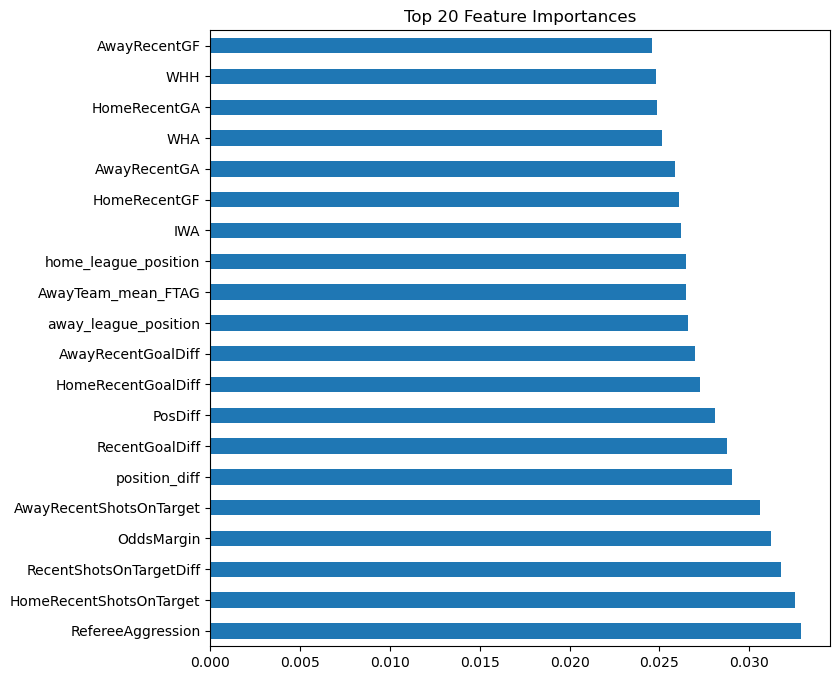

In [52]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
    'FTR', 'HTR',
    'HomeTeam', 'AwayTeam',
    'Date', 'Referee',
    'Season',
    'HomeGoalDiff', 'AwayGoalDiff',
    'HomePts', 'AwayPts'    
    ]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['GoalsOver2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances')
plt.show()

In [47]:
print(feat_importances)

IWH                  0.024410
IWD                  0.023636
IWA                  0.025573
WHH                  0.027123
WHD                  0.022250
                       ...   
OU_OddsMargin        0.010305
OverUnderRatio       0.009864
Weekend              0.005060
RefereeAggression    0.033683
EarlySeason          0.005059
Length: 129, dtype: float64


In [48]:
feat_importances.to_string('feature_importances.txt')